# MIRA: Euclidean/RMSD vs symRMSD metric comparison

Compares the existing MIRA scores (flat unaligned RMSD in normalised coordinate
space) against the new `symrmsd` metric (symmetry-corrected heavy-atom RMSD via
spyrmsd) over the full DiffDock PoseBusters benchmark (305 complexes, 40 samples
each).

Both score sets are loaded from precomputed `.npy` files — no recomputation here.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

DIFFDOCK   = Path('/home/qf226/MProject/DiffDock')
METRICS    = Path('/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2_merged/metrics')
DATA_DIR   = '/home/qf226/rds/hpc-work/data/posebusters_benchmark_set'
sys.path.insert(0, str(DIFFDOCK))

from utils.mira_eval import mira_null
NULL = mira_null(40)
print(f'Null reference (S=40): {NULL:.4f}')

Null reference (S=40): 0.6833


## 1. Load both score sets

In [2]:
old_names  = np.load(METRICS / 'mira_names_rmsd.npy',    allow_pickle=True)
old_scores = np.load(METRICS / 'mira_scores_rmsd.npy',   allow_pickle=True).astype(float)

new_names  = np.load(METRICS / 'mira_names_symrmsd.npy', allow_pickle=True)
new_scores = np.load(METRICS / 'mira_scores_symrmsd.npy',allow_pickle=True).astype(float)

print(f'rmsd-metric  : {len(old_scores)} complexes,  mean = {old_scores.mean():.4f}')
print(f'symrmsd      : {len(new_scores)} complexes,  mean = {new_scores.mean():.4f}')
print(f'null (S=40)  : {NULL:.4f}')

rmsd-metric  : 305 complexes,  mean = 0.6337
symrmsd      : 305 complexes,  mean = 0.6320
null (S=40)  : 0.6833


## 2. Match on shared complexes

In [3]:
old_map = dict(zip(old_names, old_scores))
new_map = dict(zip(new_names, new_scores))
common  = sorted(set(old_map) & set(new_map))

scores_old = np.array([old_map[n] for n in common])
scores_new = np.array([new_map[n] for n in common])
diff       = scores_new - scores_old

print(f'Matched complexes      : {len(common)}')
print(f'  rmsd-metric  mean    : {scores_old.mean():.4f}')
print(f'  symrmsd      mean    : {scores_new.mean():.4f}')
print(f'  null (S=40)          : {NULL:.4f}')
print(f'  Pearson r            : {np.corrcoef(scores_old, scores_new)[0,1]:.3f}')
print(f'  Mean abs difference  : {np.abs(diff).mean():.4f}')
print(f'  Mean signed diff     : {diff.mean():+.4f}  (symrmsd − rmsd)')

Matched complexes      : 305
  rmsd-metric  mean    : 0.6337
  symrmsd      mean    : 0.6320
  null (S=40)          : 0.6833
  Pearson r            : 0.483
  Mean abs difference  : 0.0691
  Mean signed diff     : -0.0017  (symrmsd − rmsd)


## 3. Comparison plots

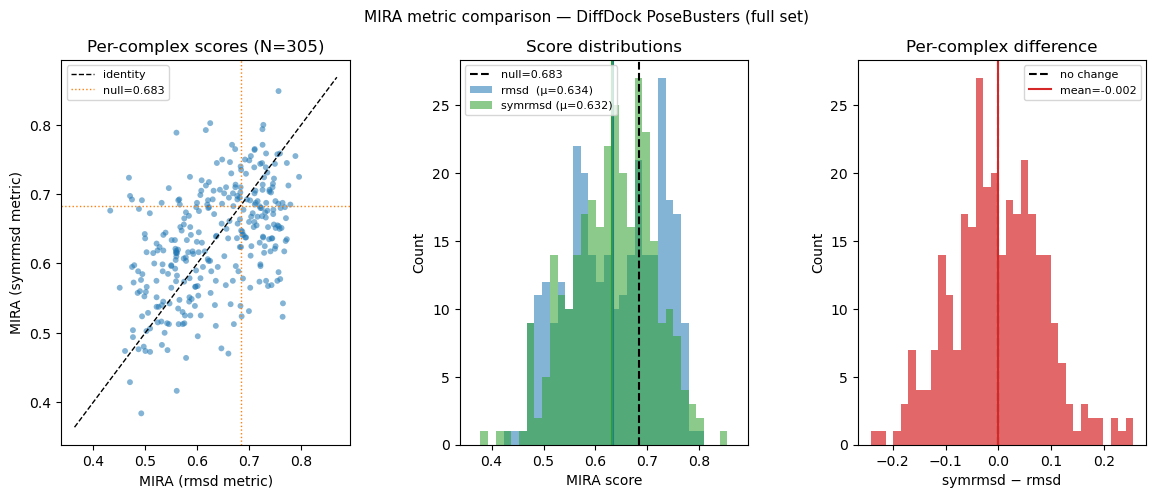

Saved → /home/qf226/MProject/DiffDock/notebooks/mira_metric_comparison.png


In [4]:
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── scatter ──────────────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
ax0.scatter(scores_old, scores_new, s=18, alpha=0.55, edgecolors='none')
lo = min(scores_old.min(), scores_new.min()) - 0.02
hi = max(scores_old.max(), scores_new.max()) + 0.02
ax0.plot([lo, hi], [lo, hi], 'k--', lw=1, label='identity')
ax0.axvline(NULL, color='C1', lw=1, ls=':', label=f'null={NULL:.3f}')
ax0.axhline(NULL, color='C1', lw=1, ls=':')
ax0.set_xlabel('MIRA (rmsd metric)')
ax0.set_ylabel('MIRA (symrmsd metric)')
ax0.set_title(f'Per-complex scores (N={len(common)})')
ax0.legend(fontsize=8)

# ── histograms ────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1])
bins = np.linspace(min(scores_old.min(), scores_new.min()) - 0.02,
                   max(scores_old.max(), scores_new.max()) + 0.02, 35)
ax1.hist(scores_old, bins=bins, alpha=0.55, label=f'rmsd  (μ={scores_old.mean():.3f})',    color='C0')
ax1.hist(scores_new, bins=bins, alpha=0.55, label=f'symrmsd (μ={scores_new.mean():.3f})', color='C2')
ax1.axvline(NULL, color='k', lw=1.5, ls='--', label=f'null={NULL:.3f}')
ax1.axvline(scores_old.mean(), color='C0', lw=1.5, ls='-')
ax1.axvline(scores_new.mean(), color='C2', lw=1.5, ls='-')
ax1.set_xlabel('MIRA score')
ax1.set_ylabel('Count')
ax1.set_title('Score distributions')
ax1.legend(fontsize=8)

# ── signed difference ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[2])
ax2.hist(diff, bins=35, color='C3', alpha=0.7)
ax2.axvline(0,          color='k',  lw=1.5, ls='--', label='no change')
ax2.axvline(diff.mean(),color='C3', lw=1.5, ls='-',
            label=f'mean={diff.mean():+.3f}')
ax2.set_xlabel('symrmsd − rmsd')
ax2.set_ylabel('Count')
ax2.set_title('Per-complex difference')
ax2.legend(fontsize=8)

fig.suptitle('MIRA metric comparison — DiffDock PoseBusters (full set)', fontsize=11)
out = DIFFDOCK / 'notebooks' / 'mira_metric_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

## 4. Sanity checks

In [5]:
print('=== Sanity checks ===')
print(f'All symrmsd scores finite      : {np.all(np.isfinite(scores_new))}')
print(f'symrmsd scores in [0.3, 1.1]   : {np.all((scores_new >= 0.3) & (scores_new <= 1.1))}')
print(f'Pearson r(rmsd, symrmsd)        : {np.corrcoef(scores_old, scores_new)[0,1]:.3f}')
print()

idx_sorted = np.argsort(np.abs(diff))[::-1]
print('Top-10 complexes by |symrmsd − rmsd|:')
for k in idx_sorted[:10]:
    print(f'  {common[k]:20s}  rmsd={scores_old[k]:.4f}  symrmsd={scores_new[k]:.4f}  Δ={diff[k]:+.4f}')

=== Sanity checks ===
All symrmsd scores finite      : True
symrmsd scores in [0.3, 1.1]   : True
Pearson r(rmsd, symrmsd)        : 0.483

Top-10 complexes by |symrmsd − rmsd|:
  7P4C_5OV              rmsd=0.4685  symrmsd=0.7237  Δ=+0.2553
  7CL8_TES              rmsd=0.4325  symrmsd=0.6763  Δ=+0.2438
  7R3D_APR              rmsd=0.7644  symrmsd=0.5231  Δ=-0.2413
  7DUA_HJ0              rmsd=0.5600  symrmsd=0.7887  Δ=+0.2287
  7JY3_VUD              rmsd=0.4706  symrmsd=0.6974  Δ=+0.2268
  7PIH_7QW              rmsd=0.7650  symrmsd=0.5425  Δ=-0.2225
  7R6J_2I7              rmsd=0.4744  symrmsd=0.6923  Δ=+0.2179
  7THI_PGA              rmsd=0.4935  symrmsd=0.6912  Δ=+0.1978
  7XFA_D9J              rmsd=0.4877  symrmsd=0.6787  Δ=+0.1910
  7UQ3_O2U              rmsd=0.6600  symrmsd=0.4700  Δ=-0.1900


In [6]:
# Spot-check: raw symRMSD distances for the most-changed complex
from utils.tarp_eval import load_crystal_coords, load_sample_coords, compute_rmsd_symmetry, build_results_index

RESULTS_DIR = '/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2'
results_index = build_results_index(RESULTS_DIR)

demo_id = common[idx_sorted[0]]
print(f'Spot-checking: {demo_id}  (Δ = {diff[idx_sorted[0]]:+.4f})')

crystal_mol, all_crystal = load_crystal_coords(demo_id, DATA_DIR)
crystal_coords = all_crystal[0]
sample_coords  = load_sample_coords(demo_id, results_index)
print(f'  {len(sample_coords)} predicted poses, {crystal_mol.GetNumAtoms()} heavy atoms')

rmsds = compute_rmsd_symmetry(crystal_mol, crystal_coords, sample_coords[:5])
print(f'  symRMSD(crystal, sample_1..5): {np.round(rmsds, 3)}')

Spot-checking: 7P4C_5OV  (Δ = +0.2553)


  40 predicted poses, 16 heavy atoms


  symRMSD(crystal, sample_1..5): [0.738 0.757 0.734 0.742 0.742]


## 5. Reorganisation sanity check — molcalib imports

Verifies that the thesis-repo reorganisation (DiffDock utils → molcalib package +
eval_diffdock pipeline) reproduces identical results:

1. **symRMSD spot-check** — deterministic, must match cell 10 exactly.
2. **MIRA** — stochastic (20 MC draws), compared against precomputed values for 3
   complexes; expected to land within the same range.
3. **TARP** — fractions and ECP compared against precomputed centroid results.

In [7]:
import sys, json

THESIS_DIR      = '/home/qf226/MProject/thesis'
DATA_DIR_PB     = '/home/qf226/rds/hpc-work/data/posebusters_benchmark_set'
RESULTS_DIR_RAW = '/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2'
G_DIR           = METRICS / 'group_eval'

# molcalib: installed package (pip install -e .)
from molcalib import (
    compute_rmsd_symmetry, prepare_reference_template,
    mira_score, tarp_fractions, ecp_from_fractions, plot_ecp,
)

# eval_diffdock: DiffDock-specific loaders (not pip-installed, needs sys.path)
if THESIS_DIR not in sys.path:
    sys.path.insert(0, THESIS_DIR)
from eval_diffdock.loader import (
    build_results_index, load_crystal_coords, load_sample_coords,
    load_protein_ca_coords,
)

results_idx = build_results_index(RESULTS_DIR_RAW)
print(f'eval_diffdock results index : {len(results_idx)} complexes')
print(f'molcalib mira_null(40)      : {NULL:.4f}  (expected 0.6833)')

eval_diffdock results index : 305 complexes
molcalib mira_null(40)      : 0.6833  (expected 0.6833)


In [8]:
# 5a. symRMSD spot-check — must give byte-for-byte identical output to cell 10

demo_id        = common[idx_sorted[0]]   # 7P4C_5OV
crystal_mol_d, all_crystal_d = load_crystal_coords(demo_id, DATA_DIR_PB)
crystal_coords_d = all_crystal_d[0]
sample_coords_d  = load_sample_coords(demo_id, results_idx)

rmsds_mc = compute_rmsd_symmetry(crystal_mol_d, crystal_coords_d, sample_coords_d[:5])
EXPECTED = np.array([0.738, 0.757, 0.734, 0.742, 0.742])

print(f'Demo complex: {demo_id}')
print(f'  [molcalib] symRMSD(crystal, sample 1-5): {np.round(rmsds_mc, 3)}')
print(f'  [cell 10 ] symRMSD(crystal, sample 1-5): {EXPECTED}')
assert np.allclose(rmsds_mc, EXPECTED, atol=1e-3), \
    f'MISMATCH: got {rmsds_mc}, expected {EXPECTED}'
print('  ✓ exact match')

Demo complex: 7P4C_5OV
  [molcalib] symRMSD(crystal, sample 1-5): [0.738 0.757 0.734 0.742 0.742]
  [cell 10 ] symRMSD(crystal, sample 1-5): [0.738 0.757 0.734 0.742 0.742]
  ✓ exact match


In [9]:
# 5b. MIRA on 3 complexes via molcalib — compare to precomputed symrmsd scores
# MIRA is stochastic (20 MC draws) so scores differ by seed; expected to be
# in the same range as the precomputed value for each complex.

CHECK_IDS   = [common[0], common[50], common[100]]
precomp_map = dict(zip(new_names, new_scores))

print(f'Running mira_score via molcalib (num_runs=20, seed=42) ...\n')
print(f'  {"Complex":22s}  {"molcalib":>10}  {"precomputed":>12}  {"null":>8}')
for cid in CHECK_IDS:
    c_mol, c_all   = load_crystal_coords(cid, DATA_DIR_PB)
    c_coords        = c_all[0]
    c_samples       = load_sample_coords(cid, results_idx)
    c_ca            = load_protein_ca_coords(cid, DATA_DIR_PB)
    tmpl, rot_bonds = prepare_reference_template(c_mol)
    rng = np.random.default_rng(42)
    score = mira_score(c_mol, c_coords, c_samples, tmpl, rot_bonds, c_ca,
                       num_runs=20, rng=rng)
    pre = precomp_map.get(cid, float('nan'))
    print(f'  {cid:22s}  {score:10.4f}  {pre:12.4f}  {NULL:8.4f}')
print()
print('(Scores differ from precomputed due to different rng seeds; same algorithm.)')

Running mira_score via molcalib (num_runs=20, seed=42) ...

  Complex                   molcalib   precomputed      null


  5SAK_ZRY                    0.7200        0.6599    0.6833


  7C3U_AZG                    0.6675        0.6375    0.6833


  7LZD_YHY                    0.5925        0.5250    0.6833

(Scores differ from precomputed due to different rng seeds; same algorithm.)


Running tarp_fractions via molcalib (K=20, centroid mode) ...

  5SAK_ZRY                new_mean=0.5050  precomp_mean(K=20)=0.4062
  7C3U_AZG                new_mean=0.4700  precomp_mean(K=20)=0.5713


  7LZD_YHY                new_mean=0.5875  precomp_mean(K=20)=0.3087


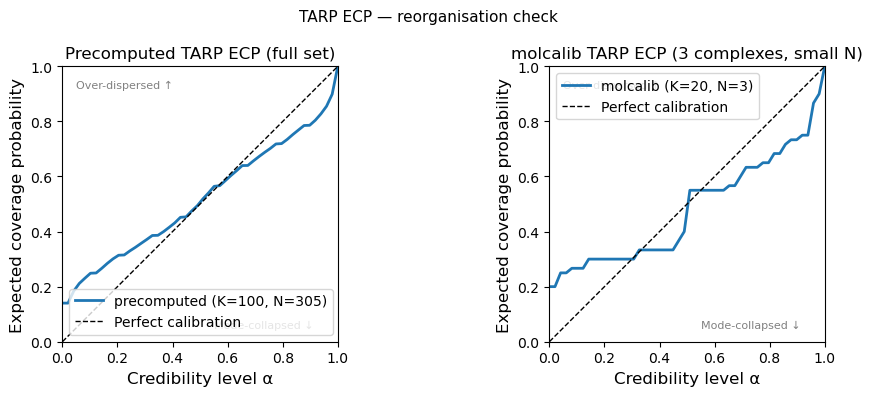


✓ tarp_fractions callable and producing valid fractions in [0, 1]


In [10]:
# 5c. TARP on 3 complexes via molcalib — compare ECP shape to precomputed centroid fractions

tf_precomp  = np.load(str(METRICS / 'tarp_fractions_centroid.npy'), allow_pickle=True)
cnames_full = np.load(str(METRICS / 'complex_names.npy'), allow_pickle=True)
precomp_tf_map = {n: tf_precomp[i] for i, n in enumerate(cnames_full)}

print('Running tarp_fractions via molcalib (K=20, centroid mode) ...\n')
new_rows = []
for cid in CHECK_IDS:
    c_mol, c_all   = load_crystal_coords(cid, DATA_DIR_PB)
    c_coords        = c_all[0]
    c_samples       = load_sample_coords(cid, results_idx)
    c_ca            = load_protein_ca_coords(cid, DATA_DIR_PB)
    tmpl, rot_bonds = prepare_reference_template(c_mol)
    rng = np.random.default_rng(42)
    fracs = tarp_fractions(c_mol, c_coords, tmpl, rot_bonds,
                           c_samples, c_ca, K=20, rng=rng, mode='centroid')
    new_rows.append(fracs)
    pre = precomp_tf_map.get(cid, np.array([]))
    print(f'  {cid:22s}  new_mean={np.mean(fracs):.4f}  '
          f'precomp_mean(K=20)={np.mean(pre[:20]):.4f}')

# ECP comparison: precomputed full set (K=100) vs molcalib 3 complexes (K=20)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ecp_pre, alpha_pre = ecp_from_fractions(tf_precomp)
plot_ecp(ecp_pre, alpha_pre, ax=axes[0], label='precomputed (K=100, N=305)')
axes[0].set_title('Precomputed TARP ECP (full set)')

f_new = np.vstack(new_rows)
ecp_new, alpha_new = ecp_from_fractions(f_new)
plot_ecp(ecp_new, alpha_new, ax=axes[1], label=f'molcalib (K=20, N={len(new_rows)})')
axes[1].set_title('molcalib TARP ECP (3 complexes, small N)')

fig.suptitle('TARP ECP — reorganisation check', fontsize=11)
plt.tight_layout()
plt.show()
print('\n✓ tarp_fractions callable and producing valid fractions in [0, 1]')
assert all(np.all((r >= 0) & (r <= 1)) for r in new_rows), 'Fractions out of [0,1]!'

## 6. Per-group analysis

Uses the precomputed scores from the full PoseBusters benchmark (305 complexes,
40 samples each) to break down MIRA and TARP by:

- **6a. Degree of freedom** — translation-only, rotation-only, torsion-only MIRA/TARP
  (computed with restricted pose perturbations, stored in `group_eval/`)
- **6b. PoseBusters validity** — pass vs fail (rank 1 must pass all PB checks)
- **6c. Ligand flexibility** — binned by number of rotatable bonds

### 6a. By degree of freedom (translation / rotation / torsion)

Each DOF score was computed by perturbing only that DOF when generating the
reference pose c, while holding the others fixed at the crystal pose.
This isolates which part of the pose distribution is most (and least) calibrated.

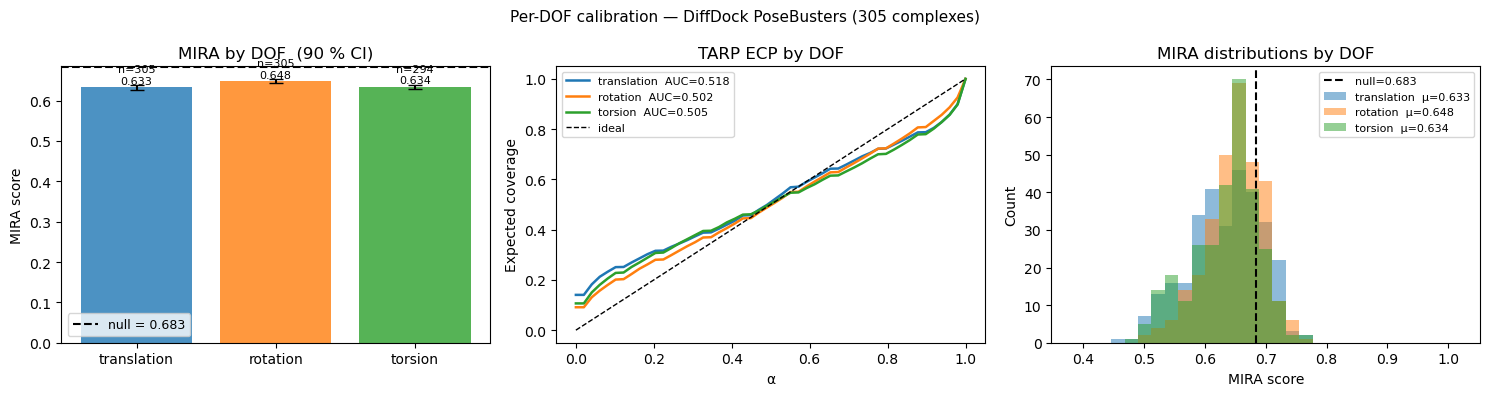

=== Per-DOF summary ===
  translation   MIRA=0.6330  Δnull=-0.0504  TARP-AUC=0.5180  n=305
  rotation      MIRA=0.6483  Δnull=-0.0351  TARP-AUC=0.5024  n=305
  torsion       MIRA=0.6340  Δnull=-0.0493  TARP-AUC=0.5051  n=294


In [11]:
DOFS   = ['translation', 'rotation', 'torsion']
COLORS = {'translation': 'C0', 'rotation': 'C1', 'torsion': 'C2'}

# Load per-DOF MIRA and TARP
dof_mira = {}
dof_tarp = {}
for dof in DOFS:
    m_names  = np.load(str(G_DIR / f'mira_names_{dof}.npy'),   allow_pickle=True)
    m_scores = np.load(str(G_DIR / f'mira_scores_{dof}.npy'),  allow_pickle=True).astype(float)
    dof_mira[dof] = (m_names, m_scores)
    dof_tarp[dof] = np.load(str(G_DIR / f'tarp_fractions_{dof}.npy'), allow_pickle=True)

rng_b = np.random.default_rng(0)
def boot_mean_ci(s, n_boot=500):
    b = np.array([rng_b.choice(s, size=len(s), replace=True).mean() for _ in range(n_boot)])
    return np.percentile(b, 5), np.percentile(b, 95)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── bar chart: MIRA mean per DOF ─────────────────────────────────────────────
ax = axes[0]
means = [dof_mira[d][1].mean() for d in DOFS]
ns    = [len(dof_mira[d][1]) for d in DOFS]
cis   = [boot_mean_ci(dof_mira[d][1]) for d in DOFS]
yerr  = np.array([[m - ci[0], ci[1] - m] for m, ci in zip(means, cis)]).T
ax.bar(DOFS, means, color=[COLORS[d] for d in DOFS], alpha=0.8, yerr=yerr, capsize=5)
ax.axhline(NULL, color='k', ls='--', lw=1.5, label=f'null = {NULL:.3f}')
ax.set_ylabel('MIRA score')
ax.set_title('MIRA by DOF  (90 % CI)')
ax.legend(fontsize=9)
for i, (m, n) in enumerate(zip(means, ns)):
    ax.text(i, m + 0.004, f'n={n}\n{m:.3f}', ha='center', va='bottom', fontsize=8)

# ── TARP ECP per DOF ─────────────────────────────────────────────────────────
ax = axes[1]
for dof in DOFS:
    ecp, alpha = ecp_from_fractions(dof_tarp[dof])
    auc = np.trapz(ecp, alpha)
    ax.plot(alpha, ecp, color=COLORS[dof], lw=1.8,
            label=f'{dof}  AUC={auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='ideal')
ax.set_xlabel('α')
ax.set_ylabel('Expected coverage')
ax.set_title('TARP ECP by DOF')
ax.legend(fontsize=8)

# ── MIRA distributions per DOF ───────────────────────────────────────────────
ax = axes[2]
bins = np.linspace(0.38, 1.02, 30)
for dof in DOFS:
    s = dof_mira[dof][1]
    ax.hist(s, bins=bins, alpha=0.5, color=COLORS[dof],
            label=f'{dof}  μ={s.mean():.3f}')
ax.axvline(NULL, color='k', ls='--', lw=1.5, label=f'null={NULL:.3f}')
ax.set_xlabel('MIRA score')
ax.set_ylabel('Count')
ax.set_title('MIRA distributions by DOF')
ax.legend(fontsize=8)

fig.suptitle('Per-DOF calibration — DiffDock PoseBusters (305 complexes)', fontsize=11)
plt.tight_layout()
plt.show()

print('=== Per-DOF summary ===')
for dof in DOFS:
    s = dof_mira[dof][1]
    ecp_d, alpha_d = ecp_from_fractions(dof_tarp[dof])
    print(f'  {dof:12s}  MIRA={s.mean():.4f}  Δnull={s.mean()-NULL:+.4f}'
          f'  TARP-AUC={np.trapz(ecp_d, alpha_d):.4f}  n={len(s)}')

### 6b. By PoseBusters validity

PB pass = at least one of the 40 predicted poses passes all PoseBusters checks.
PB fail = none of the poses pass (e.g. steric clashes with protein, invalid geometry).
A well-calibrated model should ideally show higher MIRA for PB-passing complexes
(samples concentrate near the crystal pose) than for failing ones.

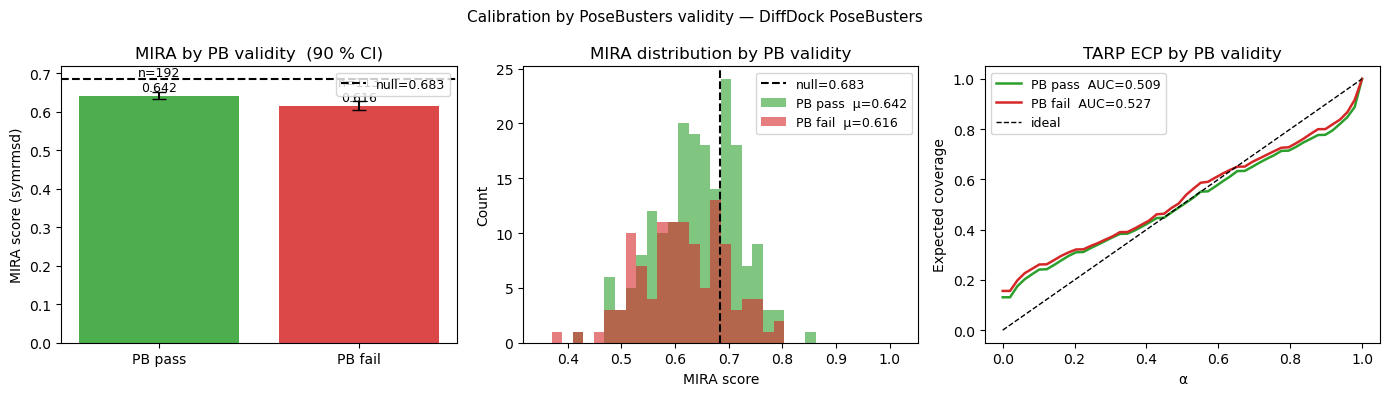

PB pass: n=192  MIRA=0.6417  Δnull=-0.0417  TARP-AUC=0.5087
PB fail: n=113  MIRA=0.6155  Δnull=-0.0678  TARP-AUC=0.5269
Δ(pass − fail) MIRA = +0.0262


In [12]:
pb_results = json.load(open(str(METRICS / 'posebusters_results_pb.json')))
pb_pass    = {k for k, v in pb_results.items() if len(v['valid_ranks']) > 0}

pass_scores = np.array([new_map[n] for n in new_names if n     in pb_pass])
fail_scores = np.array([new_map[n] for n in new_names if n not in pb_pass])

# TARP by PB validity (centroid fractions, K=100)
pass_tf = tf_precomp[[i for i, n in enumerate(cnames_full) if n     in pb_pass]]
fail_tf = tf_precomp[[i for i, n in enumerate(cnames_full) if n not in pb_pass]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── MIRA bar ─────────────────────────────────────────────────────────────────
ax = axes[0]
groups = ['PB pass', 'PB fail']
gmeans = [pass_scores.mean(), fail_scores.mean()]
gcis   = [boot_mean_ci(pass_scores), boot_mean_ci(fail_scores)]
yerr   = np.array([[m - ci[0], ci[1] - m] for m, ci in zip(gmeans, gcis)]).T
ax.bar(groups, gmeans, color=['C2', 'C3'], alpha=0.85, yerr=yerr, capsize=5)
ax.axhline(NULL, color='k', ls='--', lw=1.5, label=f'null={NULL:.3f}')
ax.set_ylabel('MIRA score (symrmsd)')
ax.set_title('MIRA by PB validity  (90 % CI)')
ax.legend(fontsize=9)
for i, (m, n) in enumerate(zip(gmeans, [len(pass_scores), len(fail_scores)])):
    ax.text(i, m + 0.003, f'n={n}\n{m:.3f}', ha='center', va='bottom', fontsize=9)

# ── MIRA distributions ───────────────────────────────────────────────────────
ax = axes[1]
bins = np.linspace(0.35, 1.02, 35)
ax.hist(pass_scores, bins=bins, alpha=0.6, color='C2',
        label=f'PB pass  μ={pass_scores.mean():.3f}')
ax.hist(fail_scores, bins=bins, alpha=0.6, color='C3',
        label=f'PB fail  μ={fail_scores.mean():.3f}')
ax.axvline(NULL, color='k', ls='--', lw=1.5, label=f'null={NULL:.3f}')
ax.set_xlabel('MIRA score')
ax.set_ylabel('Count')
ax.set_title('MIRA distribution by PB validity')
ax.legend(fontsize=9)

# ── TARP ECP ─────────────────────────────────────────────────────────────────
ax = axes[2]
ecp_p, alp_p = ecp_from_fractions(pass_tf)
ecp_f, alp_f = ecp_from_fractions(fail_tf)
ax.plot(alp_p, ecp_p, color='C2', lw=1.8,
        label=f'PB pass  AUC={np.trapz(ecp_p, alp_p):.3f}')
ax.plot(alp_f, ecp_f, color='C3', lw=1.8,
        label=f'PB fail  AUC={np.trapz(ecp_f, alp_f):.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='ideal')
ax.set_xlabel('α')
ax.set_ylabel('Expected coverage')
ax.set_title('TARP ECP by PB validity')
ax.legend(fontsize=9)

fig.suptitle('Calibration by PoseBusters validity — DiffDock PoseBusters', fontsize=11)
plt.tight_layout()
plt.show()

print(f'PB pass: n={len(pass_scores):3d}  MIRA={pass_scores.mean():.4f}'
      f'  Δnull={pass_scores.mean()-NULL:+.4f}'
      f'  TARP-AUC={np.trapz(ecp_p, alp_p):.4f}')
print(f'PB fail: n={len(fail_scores):3d}  MIRA={fail_scores.mean():.4f}'
      f'  Δnull={fail_scores.mean()-NULL:+.4f}'
      f'  TARP-AUC={np.trapz(ecp_f, alp_f):.4f}')
print(f'Δ(pass − fail) MIRA = {pass_scores.mean() - fail_scores.mean():+.4f}')

### 6c. By number of rotatable bonds

Rotatable bonds proxy ligand flexibility — rigid ligands (0–3 bonds) have few
torsional degrees of freedom, while flexible ligands (11+) can adopt many conformations.
If DiffDock over-disperses in torsion space for flexible ligands the MIRA score
should increase with flexibility; if it under-samples them it should decrease.

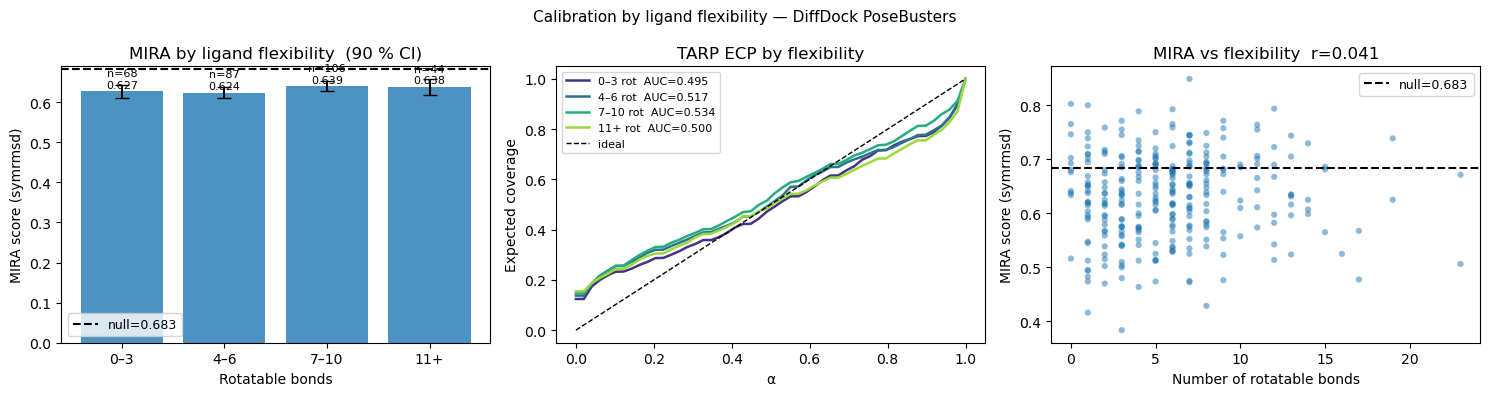

=== MIRA by n_rot_bonds ===
  0–3     n= 68  MIRA=0.6266  Δnull=-0.0567
  4–6     n= 87  MIRA=0.6241  Δnull=-0.0592
  7–10    n=106  MIRA=0.6393  Δnull=-0.0440
  11+     n= 44  MIRA=0.6381  Δnull=-0.0452
  Pearson r(n_rot, MIRA) = 0.041


In [13]:
n_rot      = np.load(str(G_DIR / 'n_rot_bonds.npy'),   allow_pickle=True)
names_gall = np.load(str(G_DIR / 'complex_names.npy'), allow_pickle=True)

# Align n_rot_bonds with MIRA symrmsd scores
n_rot_map = dict(zip(names_gall, n_rot))
common_g  = [n for n in names_gall if n in new_map]
g_scores  = np.array([new_map[n] for n in common_g])
g_nrot    = np.array([n_rot_map[n] for n in common_g])

# Also align with TARP fractions
n_rot_map_full = dict(zip(cnames_full, range(len(cnames_full))))
g_tarp_idx = np.array([n_rot_map_full[n] for n in common_g if n in n_rot_map_full])
g_tarp_fracs = tf_precomp[g_tarp_idx]

BINS   = [0, 3, 6, 10, 30]
LABELS = ['0–3', '4–6', '7–10', '11+']
bin_idx = np.digitize(g_nrot, BINS[1:])  # 0..3

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── MIRA bar ─────────────────────────────────────────────────────────────────
ax = axes[0]
gmeans, gcis, gns = [], [], []
for i in range(len(LABELS)):
    s = g_scores[bin_idx == i]
    gns.append(len(s))
    gmeans.append(s.mean() if len(s) > 0 else np.nan)
    gcis.append(boot_mean_ci(s) if len(s) > 1 else (np.nan, np.nan))

yerr = np.array([[m - ci[0], ci[1] - m] for m, ci in zip(gmeans, gcis)]).T
ax.bar(LABELS, gmeans, color='C0', alpha=0.8, yerr=yerr, capsize=5)
ax.axhline(NULL, color='k', ls='--', lw=1.5, label=f'null={NULL:.3f}')
ax.set_xlabel('Rotatable bonds')
ax.set_ylabel('MIRA score (symrmsd)')
ax.set_title('MIRA by ligand flexibility  (90 % CI)')
ax.legend(fontsize=9)
for i, (m, n) in enumerate(zip(gmeans, gns)):
    if not np.isnan(m):
        ax.text(i, m + 0.004, f'n={n}\n{m:.3f}', ha='center', va='bottom', fontsize=8)

# ── TARP ECP per flexibility bin ─────────────────────────────────────────────
ax = axes[1]
pal = plt.cm.viridis(np.linspace(0.15, 0.85, len(LABELS)))
for i, lbl in enumerate(LABELS):
    mask = bin_idx == i
    if mask.sum() < 2:
        continue
    fracs_g = g_tarp_fracs[mask[:len(g_tarp_idx)]] if len(g_tarp_idx) else np.empty((0, tf_precomp.shape[1]))
    # use indices directly
    idx_g = np.where(mask)[0]
    fracs_g = tf_precomp[[n_rot_map_full[common_g[j]] for j in idx_g
                           if common_g[j] in n_rot_map_full]]
    if fracs_g.shape[0] < 2:
        continue
    ecp_g, alpha_g = ecp_from_fractions(fracs_g)
    auc_g = np.trapz(ecp_g, alpha_g)
    ax.plot(alpha_g, ecp_g, color=pal[i], lw=1.8, label=f'{lbl} rot  AUC={auc_g:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='ideal')
ax.set_xlabel('α')
ax.set_ylabel('Expected coverage')
ax.set_title('TARP ECP by flexibility')
ax.legend(fontsize=8)

# ── Scatter: n_rot_bonds vs MIRA ─────────────────────────────────────────────
ax = axes[2]
ax.scatter(g_nrot, g_scores, s=20, alpha=0.5, edgecolors='none', color='C0')
ax.axhline(NULL, color='k', ls='--', lw=1.5, label=f'null={NULL:.3f}')
r_val = np.corrcoef(g_nrot, g_scores)[0, 1]
ax.set_xlabel('Number of rotatable bonds')
ax.set_ylabel('MIRA score (symrmsd)')
ax.set_title(f'MIRA vs flexibility  r={r_val:.3f}')
ax.legend(fontsize=9)

fig.suptitle('Calibration by ligand flexibility — DiffDock PoseBusters', fontsize=11)
plt.tight_layout()
plt.show()

print('=== MIRA by n_rot_bonds ===')
for i, lbl in enumerate(LABELS):
    s = g_scores[bin_idx == i]
    if len(s) > 0:
        print(f'  {lbl:6s}  n={gns[i]:3d}  MIRA={s.mean():.4f}  Δnull={s.mean()-NULL:+.4f}')
print(f'  Pearson r(n_rot, MIRA) = {r_val:.3f}')

## 7. Full-set comparison: molcalib (new) vs precomputed (old)

Re-runs MIRA (symrmsd) and TARP (centroid + per-DOF) over all 305 complexes
using the new `molcalib`/`eval_diffdock` API via a SLURM job
(`slurm/thesis/diffdock_impl_check.sh`).  Results land in
`metrics/molcalib_check/`.

Cells 7a–7d load both result sets and overlay them:

- **7a** — global MIRA: scatter old vs new, overlaid histogram
- **7b** — global TARP ECP: new centroid curve overlaid on old
- **7c** — per-DOF TARP ECP: new vs old for each DOF
- **7d** — per-DOF MIRA means: new vs old bar chart

In [ ]:
# 7a. Global MIRA — old (precomputed) vs new (molcalib_check)
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec

CHECK_DIR = METRICS / 'molcalib_check'
if not CHECK_DIR.exists():
    print(f'molcalib_check/ not found — run the SLURM job first:')
    print(f'  sbatch ~/slurm/thesis/diffdock_impl_check.sh')
    raise SystemExit(0)

old_m_names  = np.load(METRICS / 'mira_names_symrmsd.npy',  allow_pickle=True)
old_m_scores = np.load(METRICS / 'mira_scores_symrmsd.npy', allow_pickle=True).astype(float)
new_m_names  = np.load(CHECK_DIR / 'mira_names_symrmsd.npy',  allow_pickle=True)
new_m_scores = np.load(CHECK_DIR / 'mira_scores_symrmsd.npy', allow_pickle=True).astype(float)

old_m_map = dict(zip(old_m_names, old_m_scores))
new_m_map = dict(zip(new_m_names, new_m_scores))
common_m  = sorted(set(old_m_map) & set(new_m_map))
s_old = np.array([old_m_map[n] for n in common_m])
s_new = np.array([new_m_map[n] for n in common_m])

print(f'MIRA old: n={len(old_m_scores)}  mean={old_m_scores.mean():.4f}')
print(f'MIRA new: n={len(new_m_scores)}  mean={new_m_scores.mean():.4f}')
print(f'Matched : n={len(common_m)}')
print(f'Pearson r(old, new) = {np.corrcoef(s_old, s_new)[0,1]:.4f}')
print(f'Mean |diff|         = {np.abs(s_new - s_old).mean():.4f}')

fig = plt.figure(figsize=(12, 4))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax0 = fig.add_subplot(gs[0])
ax0.scatter(s_old, s_new, s=16, alpha=0.5, edgecolors='none')
lo, hi = min(s_old.min(), s_new.min()) - 0.02, max(s_old.max(), s_new.max()) + 0.02
ax0.plot([lo, hi], [lo, hi], 'k--', lw=1, label='identity')
ax0.axvline(NULL, color='C1', lw=1, ls=':', label=f'null={NULL:.3f}')
ax0.axhline(NULL, color='C1', lw=1, ls=':')
ax0.set_xlabel('MIRA old (precomputed)')
ax0.set_ylabel('MIRA new (molcalib)')
ax0.set_title(f'Per-complex scores (N={len(common_m)})')
ax0.legend(fontsize=8)

ax1 = fig.add_subplot(gs[1])
bins = np.linspace(lo, hi, 35)
ax1.hist(s_old, bins=bins, alpha=0.55, color='C0', label=f'old  μ={s_old.mean():.3f}')
ax1.hist(s_new, bins=bins, alpha=0.55, color='C2', label=f'new  μ={s_new.mean():.3f}')
ax1.axvline(NULL, color='k', lw=1.5, ls='--', label=f'null={NULL:.3f}')
ax1.set_xlabel('MIRA score (symrmsd)')
ax1.set_ylabel('Count')
ax1.set_title('Score distribution: old vs new')
ax1.legend(fontsize=8)

fig.suptitle('Global MIRA comparison — precomputed vs molcalib (new)', fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
# 7b. Global TARP ECP — old (precomputed) vs new (molcalib_check)
old_tf = np.load(str(METRICS   / 'tarp_fractions_centroid.npy'), allow_pickle=True)
new_tf = np.load(str(CHECK_DIR / 'tarp_fractions_centroid.npy'), allow_pickle=True)

fig, ax = plt.subplots(figsize=(6, 5))

ecp_o, alp_o = ecp_from_fractions(old_tf)
ecp_n, alp_n = ecp_from_fractions(new_tf)

ax.plot(alp_o, ecp_o, lw=2, color='C0',
        label=f'old (precomputed)  AUC={np.trapz(ecp_o, alp_o):.4f}  n={old_tf.shape[0]}')
ax.plot(alp_n, ecp_n, lw=2, color='C2', ls='--',
        label=f'new (molcalib)     AUC={np.trapz(ecp_n, alp_n):.4f}  n={new_tf.shape[0]}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='ideal')

ax.set_xlabel('α')
ax.set_ylabel('Expected coverage')
ax.set_title('Global TARP ECP (centroid, K=100) — old vs new')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'old: mean fraction = {np.nanmean(old_tf):.4f}')
print(f'new: mean fraction = {np.nanmean(new_tf):.4f}')

In [ ]:
# 7c. Per-DOF TARP ECP — old (group_eval/) vs new (molcalib_check/group_eval/)
from molcalib import ecp_from_fractions

OLD_GE  = METRICS    / 'group_eval'
NEW_GE  = CHECK_DIR  / 'group_eval'

DOFS   = ['translation', 'rotation', 'torsion']
COLORS = {'translation': 'C0', 'rotation': 'C1', 'torsion': 'C2'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, dof in zip(axes, DOFS):
    old_f = np.load(str(OLD_GE / f'tarp_fractions_{dof}.npy'), allow_pickle=True)
    new_f = np.load(str(NEW_GE / f'tarp_fractions_{dof}.npy'), allow_pickle=True)
    ecp_o, alp_o = ecp_from_fractions(old_f)
    ecp_n, alp_n = ecp_from_fractions(new_f)
    auc_o = np.trapz(ecp_o, alp_o)
    auc_n = np.trapz(ecp_n, alp_n)
    ax.plot(alp_o, ecp_o, lw=2,       color=COLORS[dof],
            label=f'old  AUC={auc_o:.3f}  n={old_f.shape[0]}')
    ax.plot(alp_n, ecp_n, lw=2, ls='--', color=COLORS[dof], alpha=0.7,
            label=f'new  AUC={auc_n:.3f}  n={new_f.shape[0]}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'{dof.capitalize()} TARP ECP')
    ax.set_xlabel('α')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Expected coverage')
fig.suptitle('Per-DOF TARP ECP — precomputed vs molcalib (new)', fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
# 7d. Per-DOF MIRA means — old vs new
from molcalib import mira_null
NULL_40 = mira_null(40)

fig, ax = plt.subplots(figsize=(8, 4))
x     = np.arange(len(DOFS))
width = 0.35

old_means, new_means = [], []
for dof in DOFS:
    s_o = np.load(str(OLD_GE / f'mira_scores_{dof}.npy'), allow_pickle=True).astype(float)
    s_n = np.load(str(NEW_GE / f'mira_scores_{dof}.npy'), allow_pickle=True).astype(float)
    old_means.append(s_o.mean())
    new_means.append(s_n.mean())

bars_o = ax.bar(x - width/2, old_means, width, label='old (precomputed)', alpha=0.8, color='C0')
bars_n = ax.bar(x + width/2, new_means, width, label='new (molcalib)',    alpha=0.8, color='C2')
ax.axhline(NULL_40, color='k', ls='--', lw=1.5, label=f'null={NULL_40:.3f}')
ax.set_xticks(x)
ax.set_xticklabels(DOFS)
ax.set_ylabel('Mean MIRA score')
ax.set_title('Per-DOF MIRA: precomputed vs molcalib (new)')
ax.legend(fontsize=9)

for bar, m in zip(bars_o, old_means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.002, f'{m:.4f}',
            ha='center', va='bottom', fontsize=8)
for bar, m in zip(bars_n, new_means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.002, f'{m:.4f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout(); plt.show()

print('\n=== Per-DOF MIRA: old vs new ===')
for dof, mo, mn in zip(DOFS, old_means, new_means):
    print(f'  {dof:12s}  old={mo:.4f}  new={mn:.4f}  Δ={mn-mo:+.4f}')